In [1]:
import seaborn as sns

# Load the built-in titanic dataset
df = sns.load_dataset('titanic')

# Display the first 5 rows
print(df.head())

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


# Da fare

- ripulire il dataset
- convertire categorie in numeri
- rimuovere outlier con z-score 3
- feature engineering
- normalizzare
- applicare logistic regression

In [2]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [3]:
# Conta dei valori mancanti per colonna
print(df.isnull().sum() / len(df) * 100)

survived        0.000000
pclass          0.000000
sex             0.000000
age            19.865320
sibsp           0.000000
parch           0.000000
fare            0.000000
embarked        0.224467
class           0.000000
who             0.000000
adult_male      0.000000
deck           77.216611
embark_town     0.224467
alive           0.000000
alone           0.000000
dtype: float64


In [4]:
# 1Elimina la colonna 'deck'
df = df.drop(columns=['deck'])

# 2Riempi i valori nulli della colonna 'age' con la mediana
df['age'] = df['age'].fillna(df['age'].mean())

# 3Elimina le righe dove 'embarked' è nullo
df = df.dropna(subset=['embarked'])

# Controllo finale dei valori nulli
print(df.isnull().sum())

# Mostra le prime righe pulite
print(df.head())

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male  embark_town alive  alone  
0    man        True  Southampton    no  False  
1  woman       False    Cherbourg   yes  False  
2  woman       False  Southampton   yes   True  
3  woman       False  Southampton   yes  False  
4    man        True  Southampton    no   True 

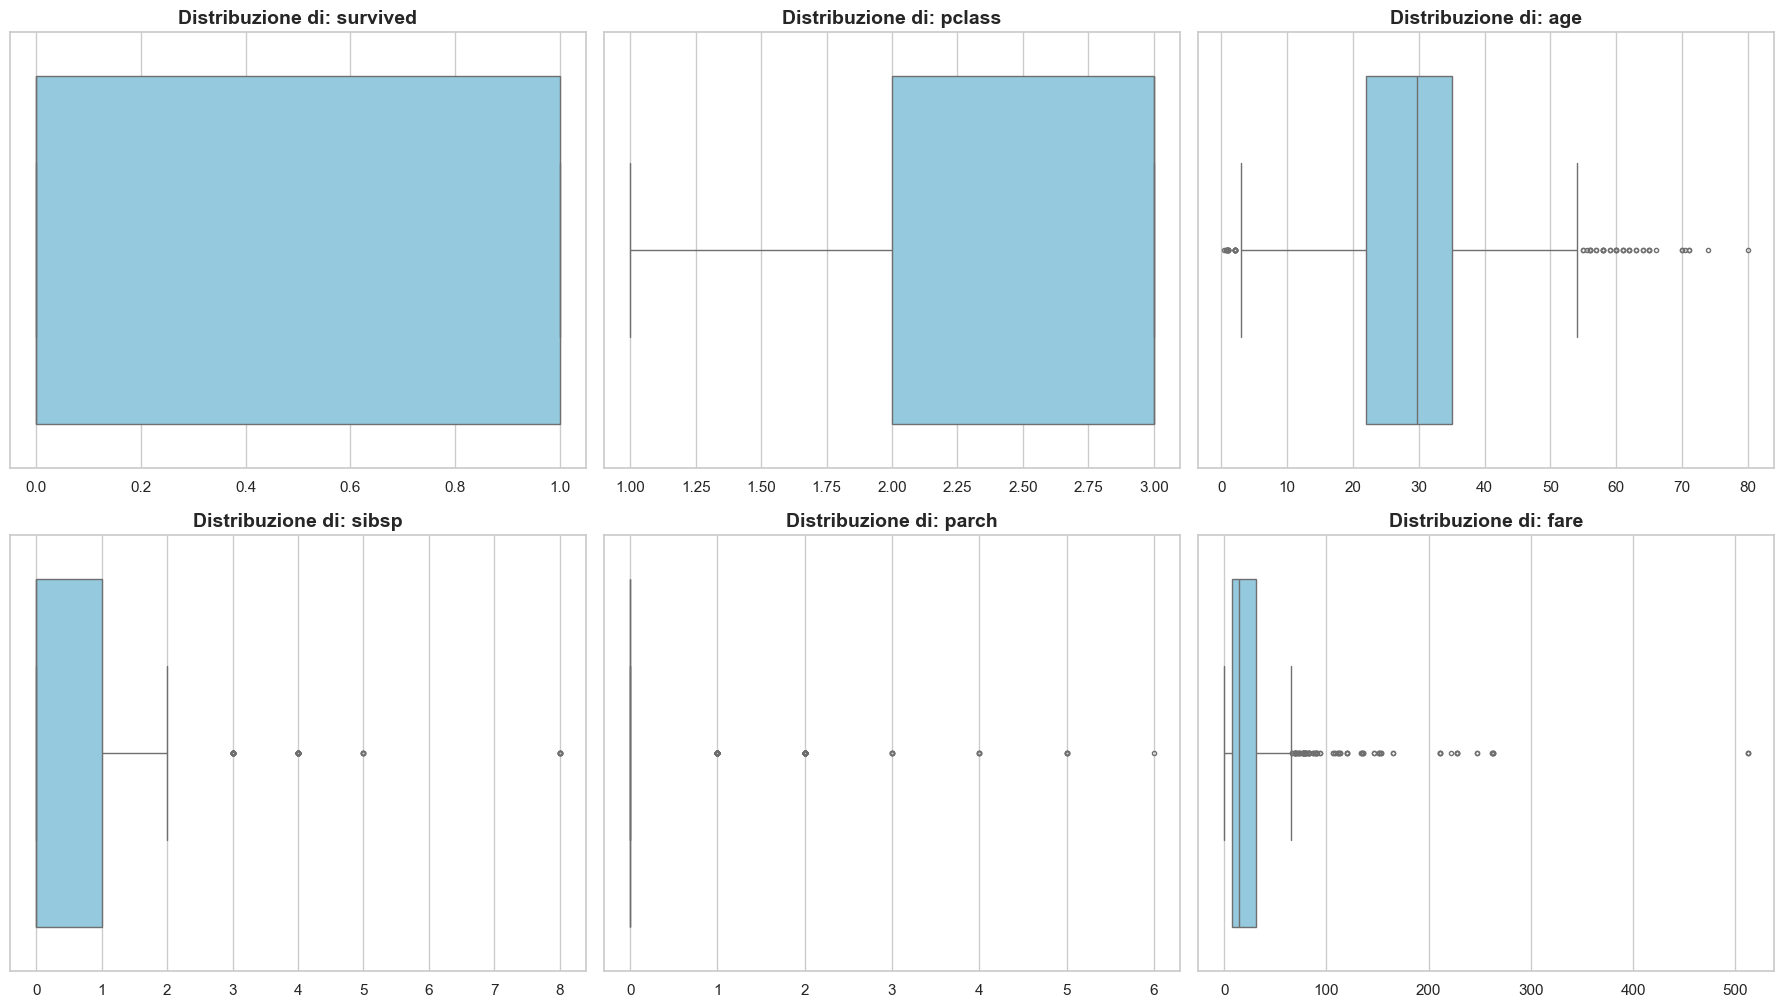

In [5]:
import matplotlib.pyplot as plt
# Impostiamo lo stile e la griglia

sns.set_theme(style="whitegrid")

# Creiamo figura 3x3
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 15))
axes = axes.flatten()

# Ciclo per creare boxplot solo per colonne numeriche
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

for i, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], ax=axes[i], color='skyblue', fliersize=3)
    axes[i].set_title(f'Distribuzione di: {col}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('')

# Rimuovo eventuali assi vuoti (se ci sono più subplot che colonne)
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

# Ottimizzazione layout
plt.tight_layout()
plt.show()

In [6]:
import numpy as np
from scipy import stats

def remove_outliers_zscore(data, columns, threshold=3):
    df_clean = data.copy()
    # Calcoliamo lo Z-score assoluto per ogni colonna selezionata
    z_scores = np.abs(stats.zscore(df_clean[columns]))

    # Teniamo solo le righe dove TUTTE le colonne hanno Z < threshold
    filtered_entries = (z_scores < threshold).all(axis=1)
    return df_clean[filtered_entries]

# Applicazione

df = remove_outliers_zscore(df, ['fare', 'parch', 'sibsp']) # age
#print(f"Righe rimosse con Z-Score: {len(df) - len(df)}")



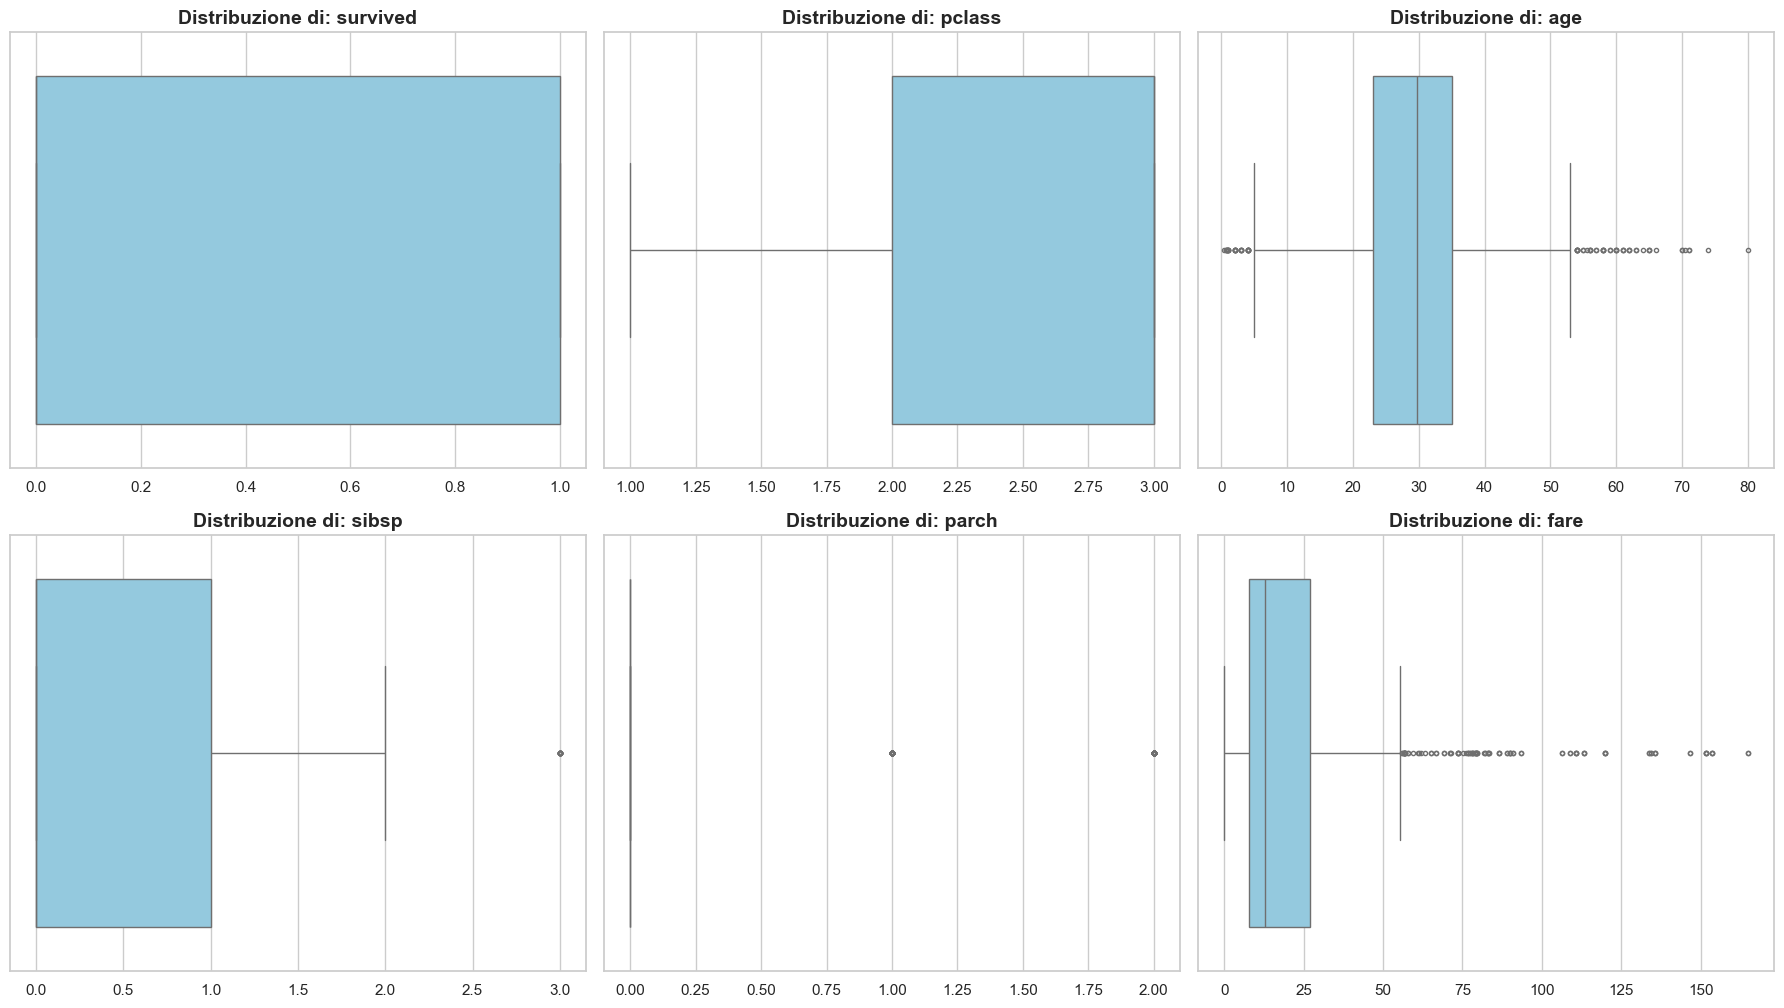

In [7]:
sns.set_theme(style="whitegrid")

# Creiamo figura 3x3
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 15))
axes = axes.flatten()

# Ciclo per creare boxplot solo per colonne numeriche
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

for i, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], ax=axes[i], color='skyblue', fliersize=3)
    axes[i].set_title(f'Distribuzione di: {col}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('')

# Rimuovo eventuali assi vuoti (se ci sono più subplot che colonne)
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

# Ottimizzazione layout
plt.tight_layout()
plt.show()

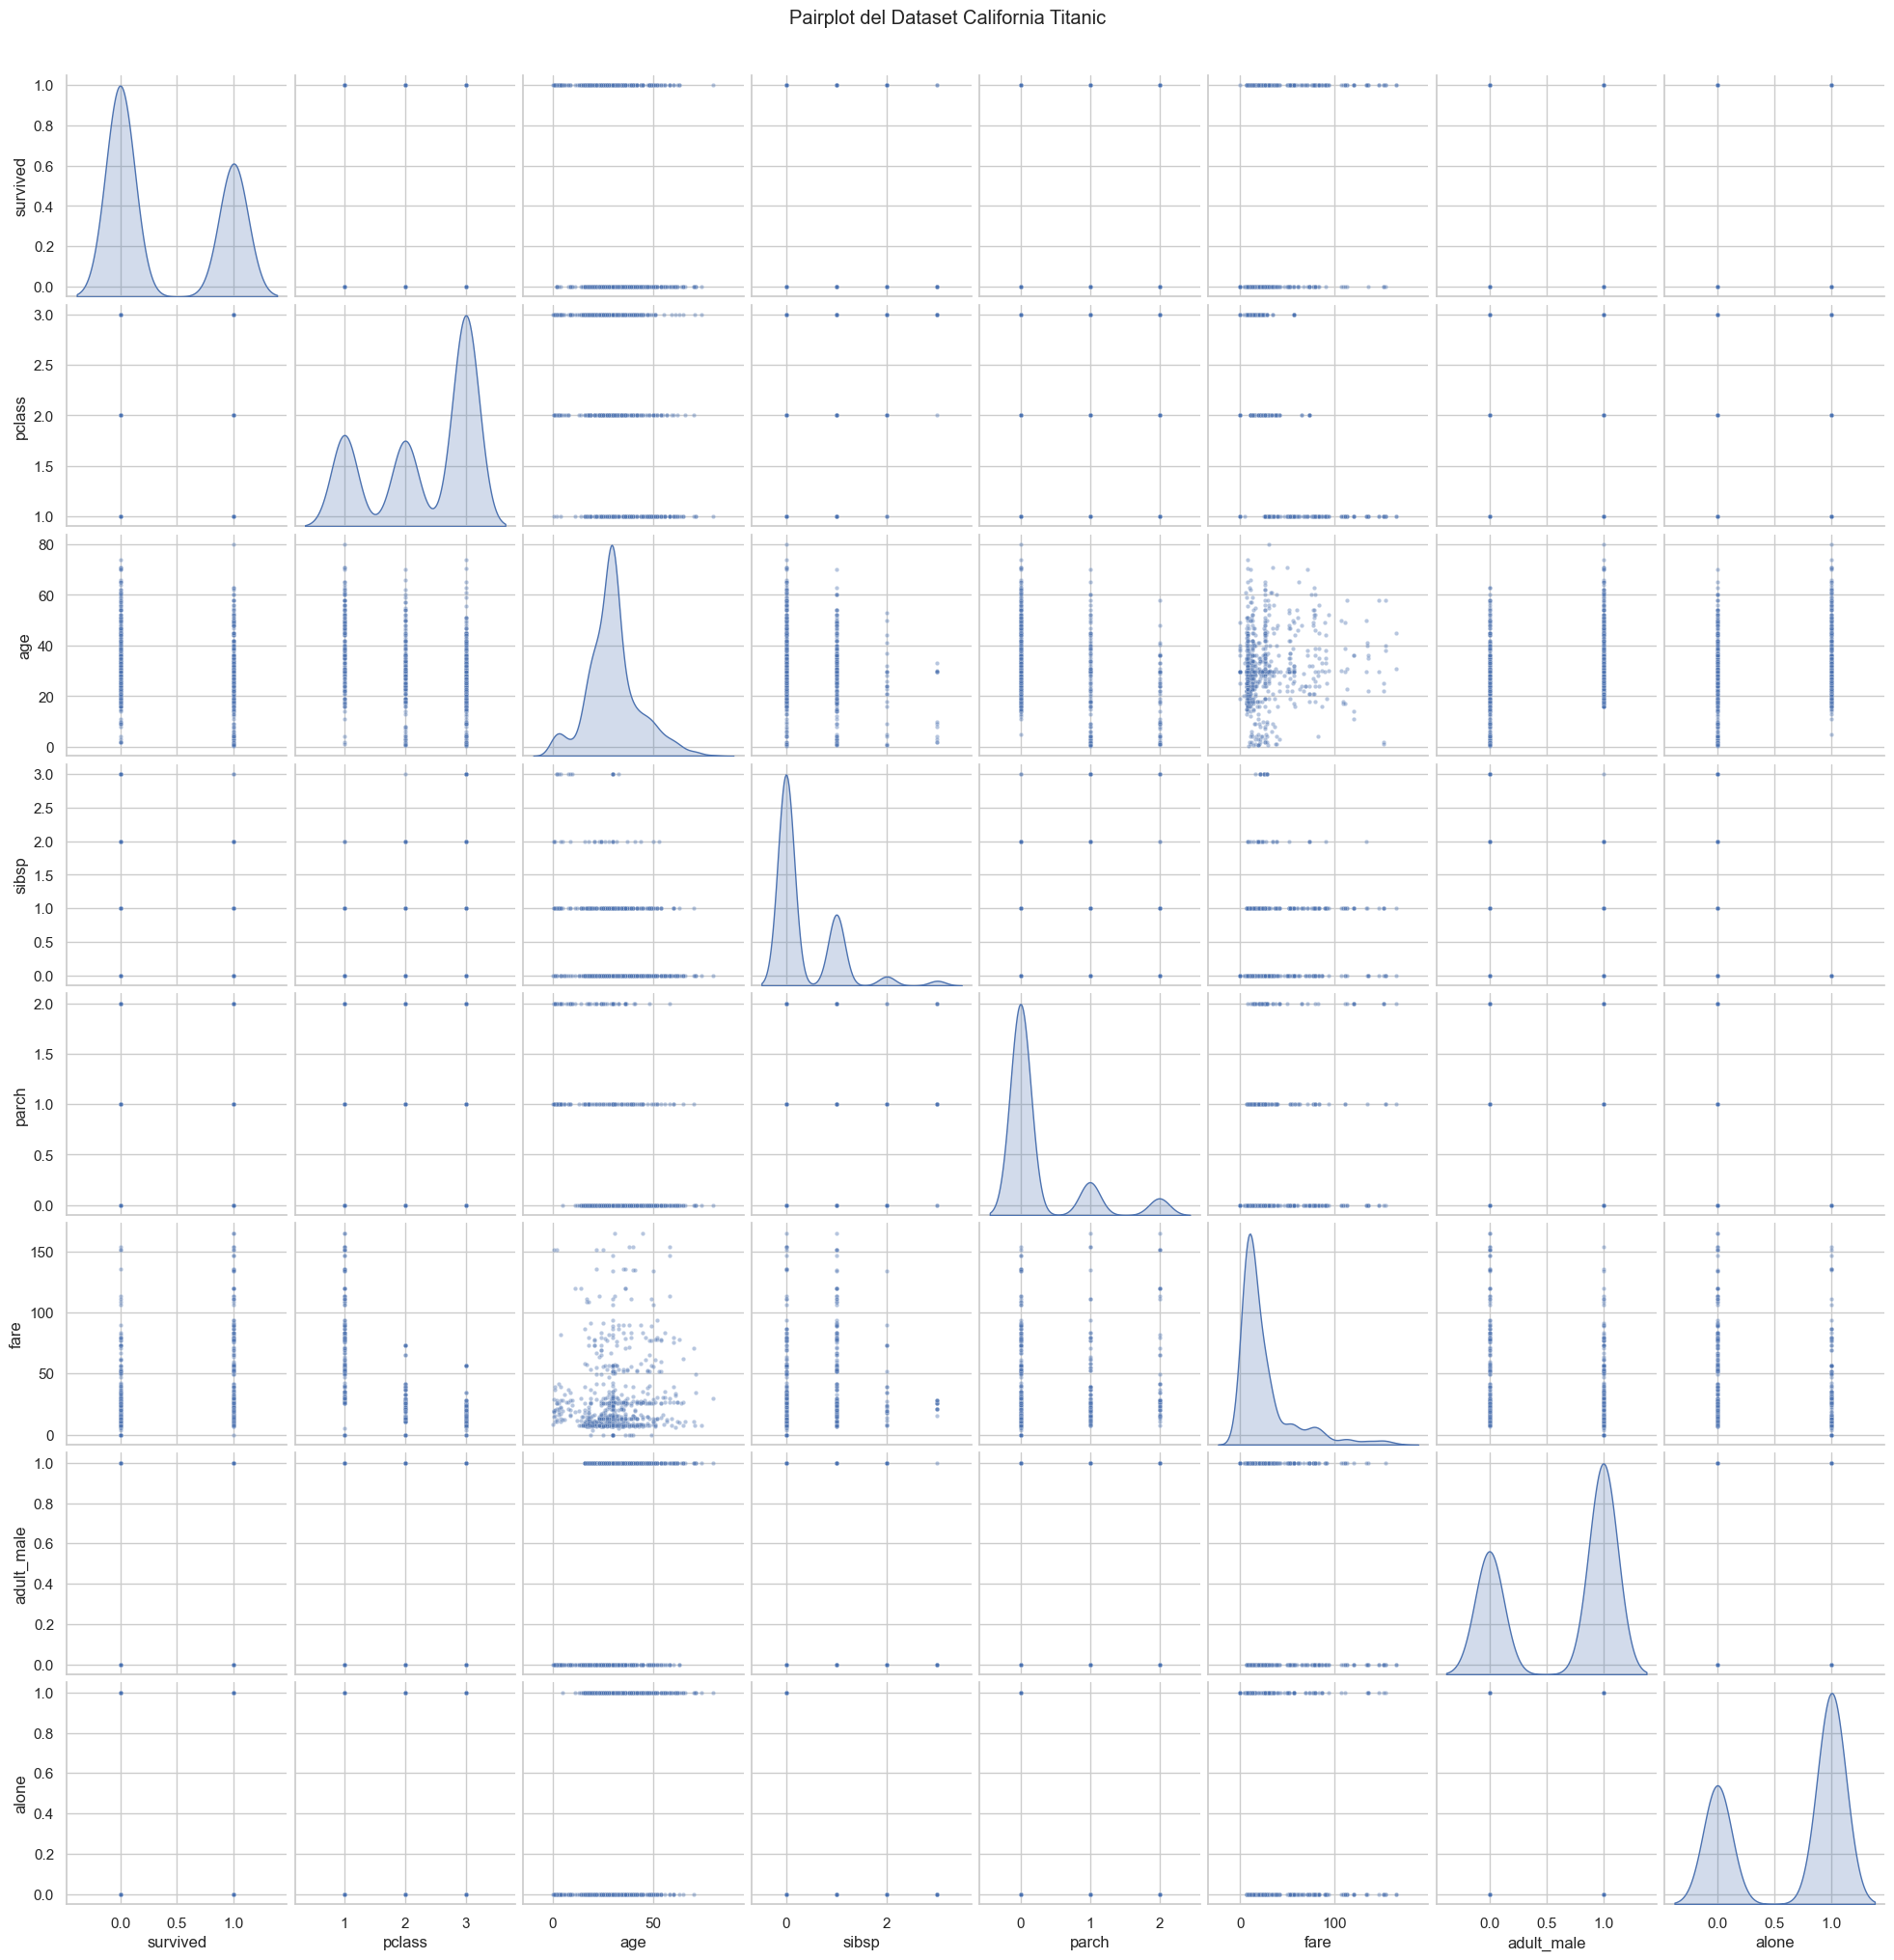

In [8]:
# Campionamento per velocità e chiarezza (es. 1000 righe)
##df = df.sample(n=, random_state=42)

# Creazione del Pairplot
# 'diag_kind' imposta i grafici sulla diagonale (istogrammi o densità KDE)
# 'plot_kws' serve per rimpicciolire i punti e renderli trasparenti
sns.pairplot(df,
    diag_kind='kde',
    plot_kws={'alpha': 0.4, 's': 10})

plt.suptitle("Pairplot del Dataset California Titanic", y=1.02)
plt.show()

In [9]:
# feature enginnering
# Famiglia totale (sibsp + parch + se stesso)
df['family_size'] = df['sibsp'] + df['parch'] + 1

df['age_log'] = np.log1p(df['age'])
df['fare_log'] = np.log1p(df['fare'])

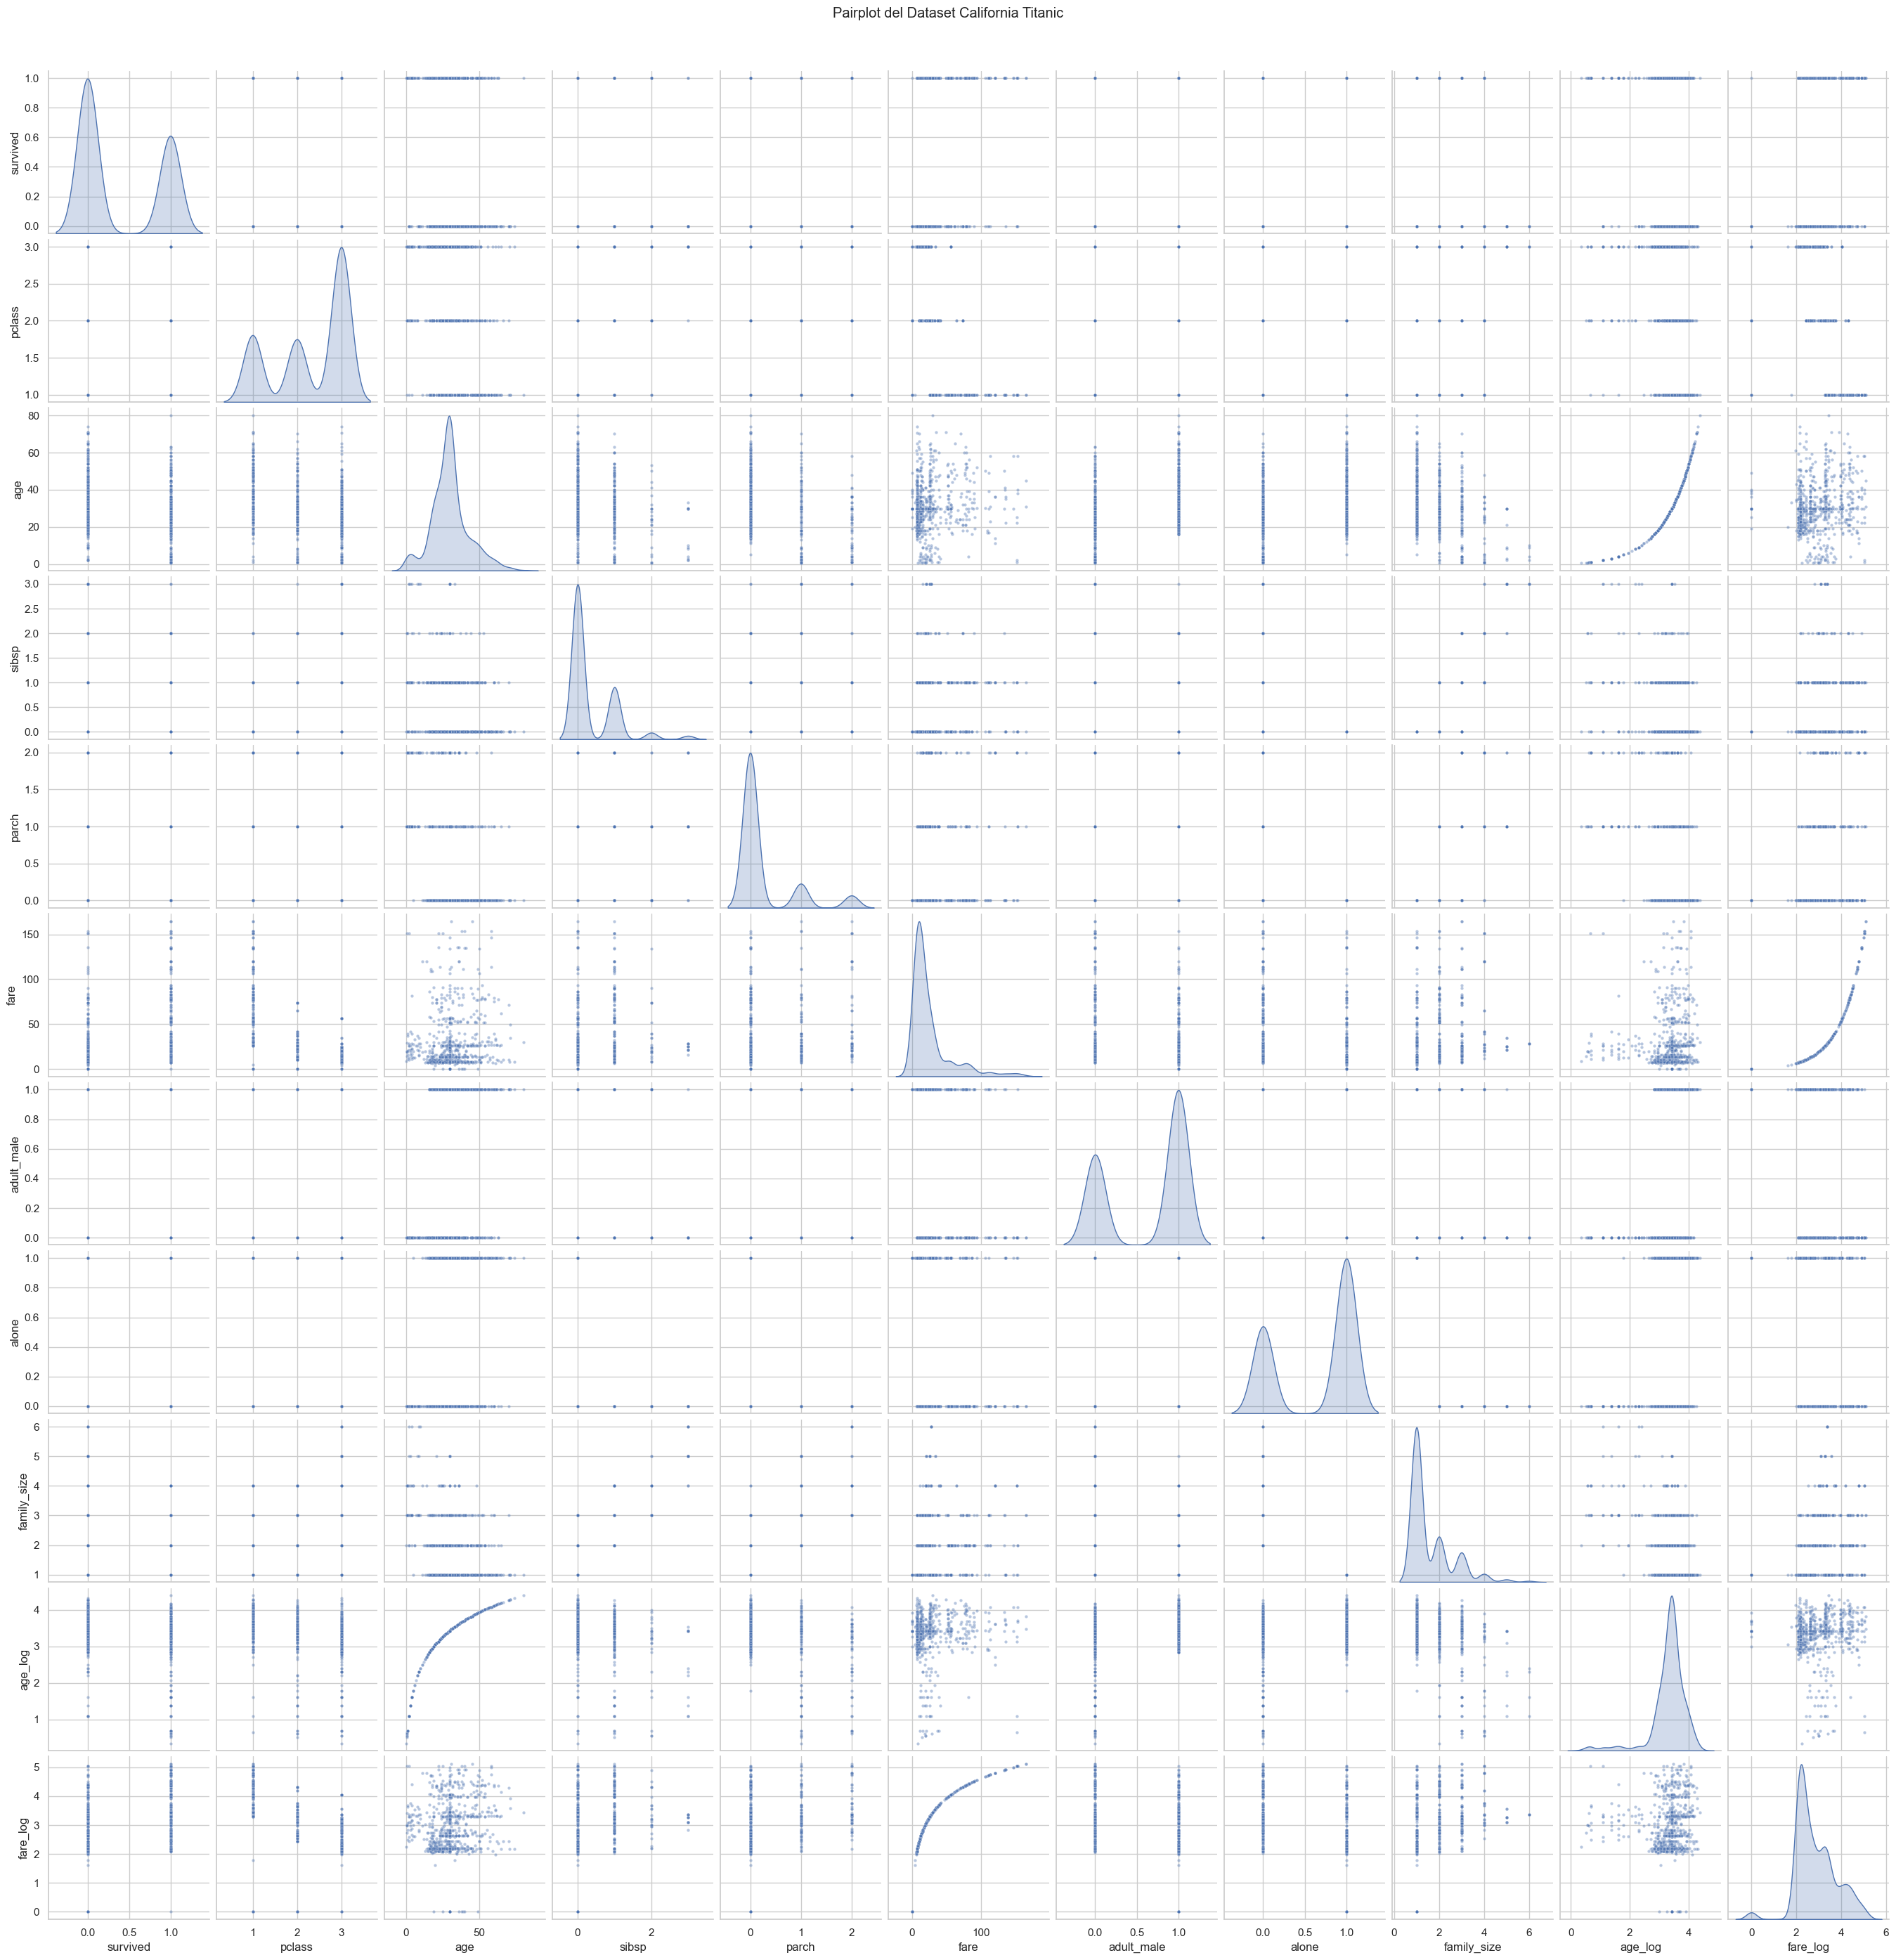

In [10]:
sns.pairplot(df,
    diag_kind='kde',
    plot_kws={'alpha': 0.4, 's': 10})

plt.suptitle("Pairplot del Dataset California Titanic", y=1.02)
plt.show()

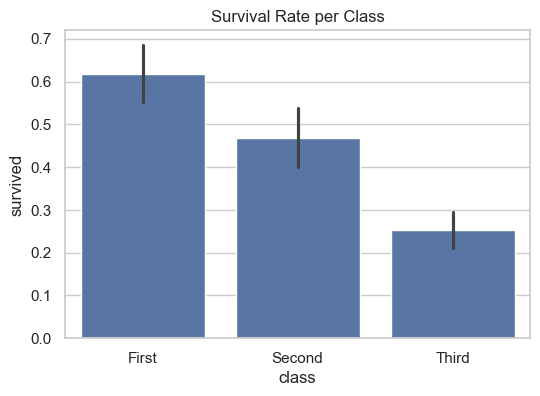

In [11]:
plt.figure(figsize=(6,4))
sns.barplot(data=df, x='class', y='survived')
plt.title("Survival Rate per Class")
plt.show()

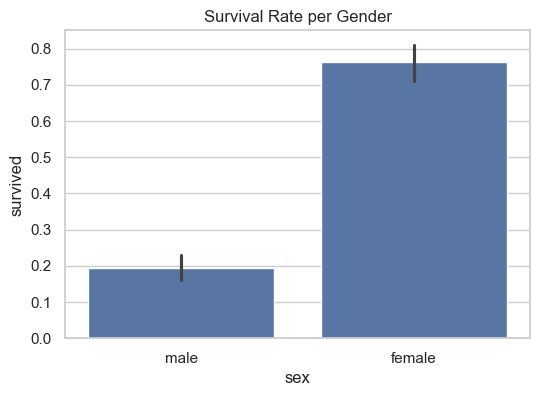

In [12]:
plt.figure(figsize=(6,4))
sns.barplot(data=df, x='sex', y='survived')
plt.title("Survival Rate per Gender")
plt.show()

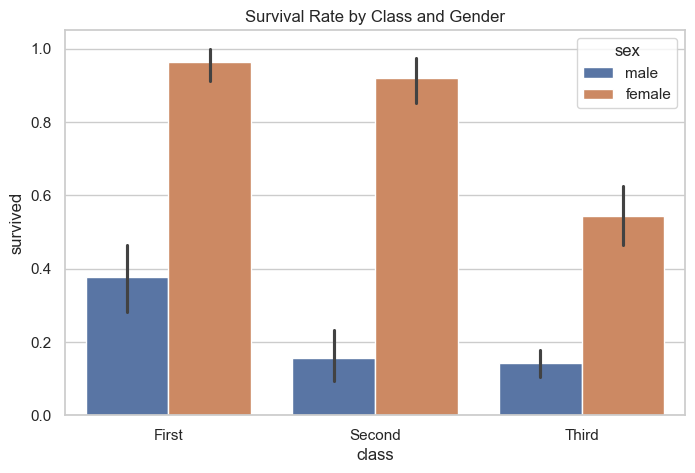

In [13]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x='class', y='survived', hue='sex')
plt.title("Survival Rate by Class and Gender")
plt.show()

In [14]:
## encoding variab categoriche
import pandas as pd

# Variabili categoriche da trasformare
categorical_cols = ['sex', 'class', 'embarked', 'who']

# One-hot encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)


In [15]:
# standard scaler
from sklearn.preprocessing import StandardScaler

# Colonne numeriche da normalizzare
#num_cols = ['age', 'fare_log', 'sibsp_log', 'parch_log', 'family_size_log']
num_cols = ['age', 'fare_log', 'sibsp', 'parch', 'family_size']


scaler = StandardScaler()
df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])

# Rimuovo colonne non numeriche inutili
#embark_town → stringa, ridondante
#alive → ridondante rispetto a survived
df_encoded = df_encoded.drop(columns=['embark_town', 'alive'])


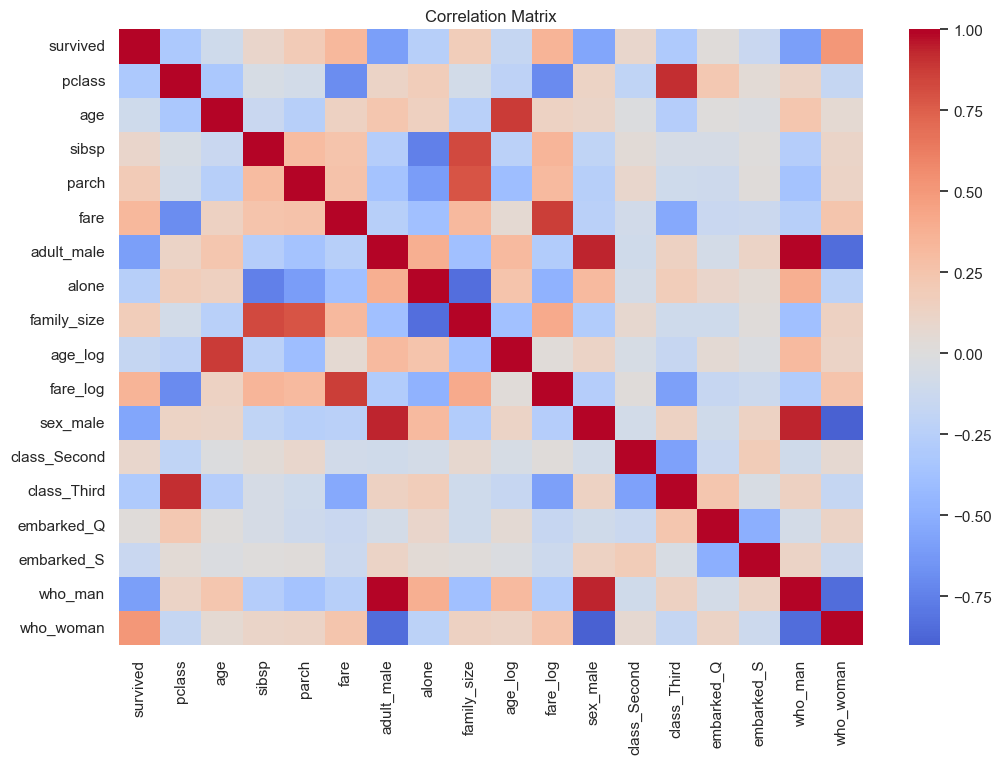

In [16]:
plt.figure(figsize=(12, 8))

# Solo colonne numeriche
corr = df_encoded.corr()

sns.heatmap(corr, annot=False, cmap="coolwarm", center=0)

plt.title("Correlation Matrix")
plt.show()

In [17]:
from sklearn.model_selection import train_test_split

# Target
y = df_encoded['survived']

# Feature ['age', 'fare_log', 'sibsp', 'parch', 'family_size', 'adult_male', 'alone','sex_male', 'class_Second', 'class_Third','embarked_Q', 'embarked_S','who_man', 'who_woman']
X = df_encoded.drop(columns=['survived'])

# Split train/test (80%-20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Creiamo il modello
logreg = LogisticRegression(max_iter=1000)  # max_iter alto per assicurare convergenza
print(X_train.dtypes)
# Alleniamo il modello
logreg.fit(X_train, y_train)

# Previsioni
y_pred = logreg.predict(X_test)

pclass            int64
age             float64
sibsp           float64
parch           float64
fare            float64
adult_male         bool
alone              bool
family_size     float64
age_log         float64
fare_log        float64
sex_male           bool
class_Second       bool
class_Third        bool
embarked_Q         bool
embarked_S         bool
who_man            bool
who_woman          bool
dtype: object


In [19]:
# Accuratezza
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Matrice di confusione
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Report dettagliato
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8182
Confusion Matrix:
[[89 13]
 [17 46]]
Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.87      0.86       102
           1       0.78      0.73      0.75        63

    accuracy                           0.82       165
   macro avg       0.81      0.80      0.80       165
weighted avg       0.82      0.82      0.82       165



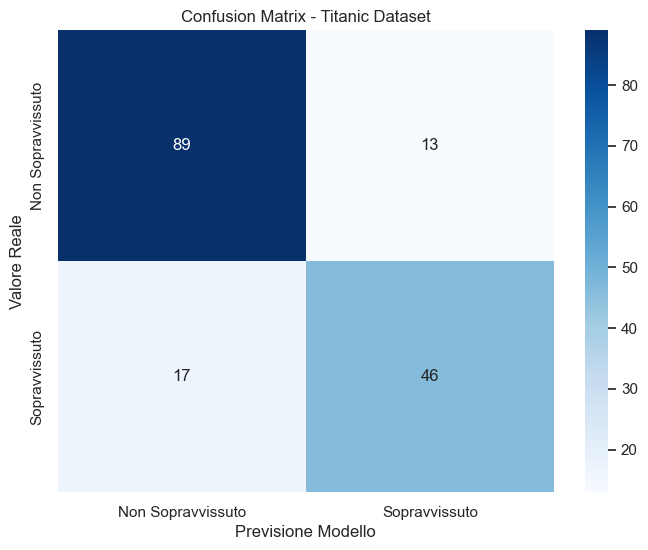

In [20]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)
# 5. Plot con Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Non Sopravvissuto', 'Sopravvissuto'], 
            yticklabels=['Non Sopravvissuto', 'Sopravvissuto'])

plt.xlabel('Previsione Modello')
plt.ylabel('Valore Reale')
plt.title('Confusion Matrix - Titanic Dataset')
plt.show()

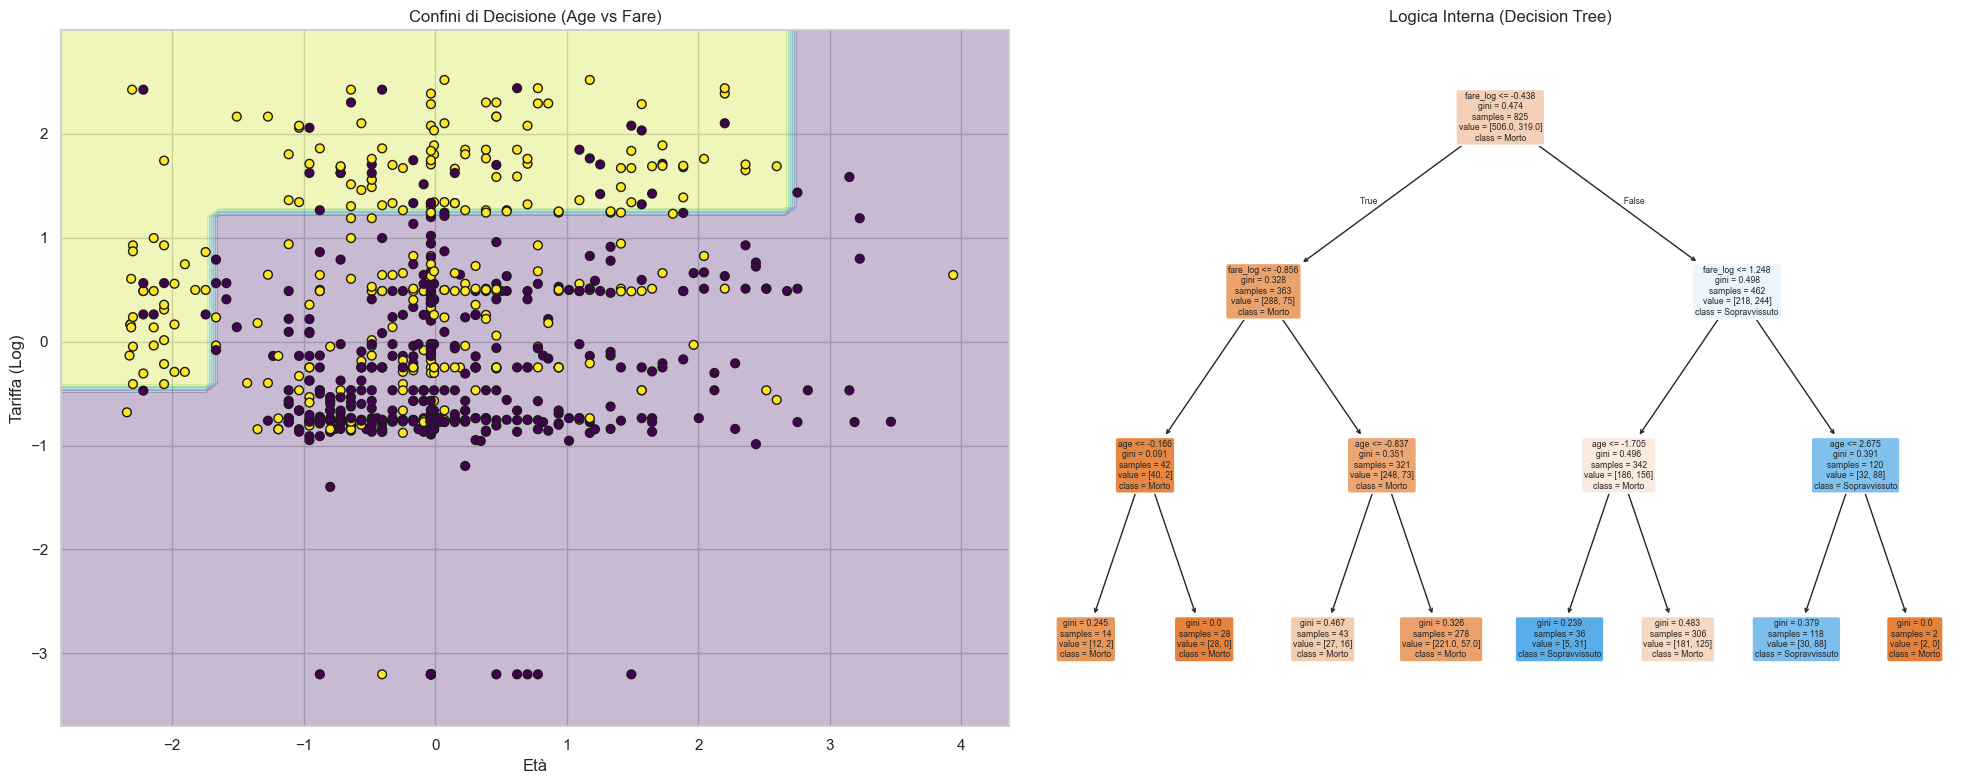

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree

#Scegliamo solo DUE feature per la visualizzazione (altrimenti non possiamo disegnare i confini)
features_visual = ['age', 'fare_log']
X_vis = df_encoded[features_visual].values
y_vis = df_encoded['survived'].values

#Addestriamo un albero "visual" su queste due sole feature
tree_clf = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_clf.fit(X_vis, y_vis)

#Creazione del grafico con due sotto-grafici
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

#--- SOTTO-GRAFICO 1: Confini di Decisione ---
x_min, x_max = X_vis[:, 0].min() - 0.5, X_vis[:, 0].max() + 0.5
y_min, y_max = X_vis[:, 1].min() - 0.5, X_vis[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), # Step più grande per velocità
                     np.arange(y_min, y_max, 0.1))

#Ora predict riceve 2 colonne, coerente con l'addestramento di tree_clf
Z = tree_clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

ax1.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
ax1.scatter(X_vis[:, 0], X_vis[:, 1], c=y_vis, edgecolors='k', s=40, cmap='viridis')
ax1.set_title("Confini di Decisione (Age vs Fare)")
ax1.set_xlabel('Età')
ax1.set_ylabel('Tariffa (Log)')

#--- SOTTO-GRAFICO 2: Struttura dell'Albero ---
plot_tree(tree_clf, 
          feature_names=features_visual,
          class_names=['Morto', 'Sopravvissuto'], 
          filled=True, rounded=True, ax=ax2)
ax2.set_title("Logica Interna (Decision Tree)")

plt.tight_layout()
plt.show()


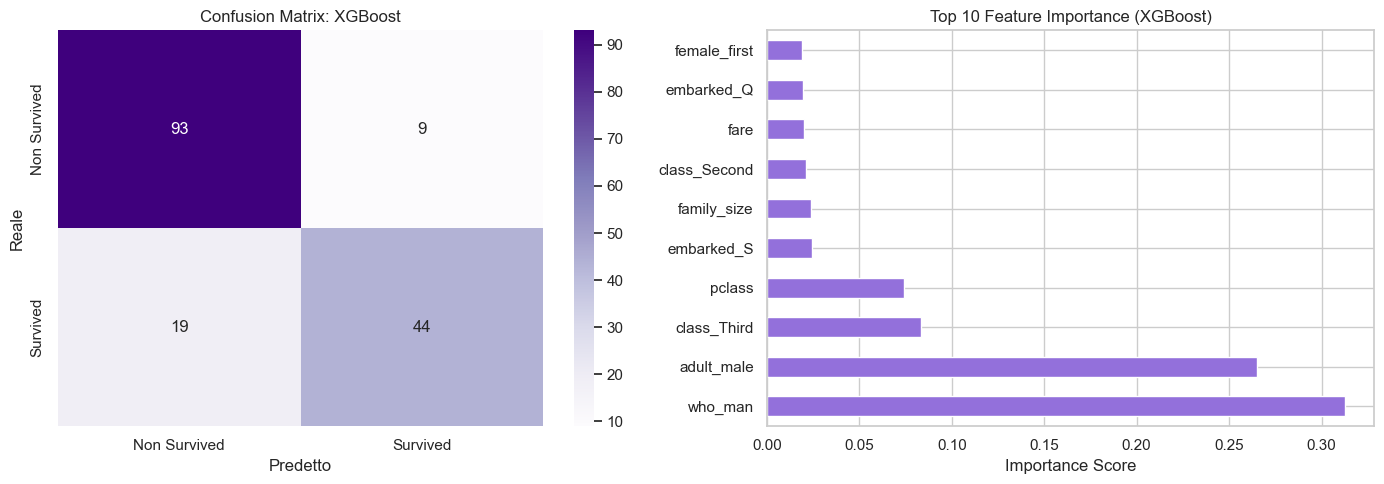

Accuratezza XGBoost: 83.03%

Report Tecnico:
              precision    recall  f1-score   support

           0       0.83      0.91      0.87       102
           1       0.83      0.70      0.76        63

    accuracy                           0.83       165
   macro avg       0.83      0.81      0.81       165
weighted avg       0.83      0.83      0.83       165



In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from xgboost import XGBClassifier

# -----------------------
# 1️⃣ Preparazione dati
# -----------------------

# female_first: donna in prima classe
df_encoded['female_first'] = ((df_encoded['sex_male'] == 0) & 
                              (df_encoded['class_Second'] == 0) & 
                              (df_encoded['class_Third'] == 0)).astype(int)

# male_third: uomo in terza classe
df_encoded['male_third'] = ((df_encoded['sex_male'] == 1) & 
                            (df_encoded['class_Third'] == 1)).astype(int)

# is_child: età < 18
df_encoded['is_child'] = (df_encoded['age'] < 18).astype(int)


# Target
y = df_encoded['survived']

# Feature
X = df_encoded.drop(columns=['survived'])

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------
# 2️⃣ Modello XGBoost
# -----------------------

xgb_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=4,
    gamma=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

# -----------------------
# 3️⃣ Addestramento
# -----------------------

xgb_model.fit(X_train, y_train)

# -----------------------
# 4️⃣ Predizione
# -----------------------

y_pred = xgb_model.predict(X_test)

# -----------------------
# 📊 VISUALIZZAZIONE
# -----------------------

plt.figure(figsize=(14, 5))

# 🔹 Confusion Matrix
plt.subplot(1, 2, 1)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Non Survived', 'Survived'],
            yticklabels=['Non Survived', 'Survived'])
plt.title('Confusion Matrix: XGBoost')
plt.xlabel('Predetto')
plt.ylabel('Reale')

# 🔹 Feature Importance
plt.subplot(1, 2, 2)
feat_importances = pd.Series(xgb_model.feature_importances_, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh', color='mediumpurple')
plt.title('Top 10 Feature Importance (XGBoost)')
plt.xlabel('Importance Score')

plt.tight_layout()
plt.show()

# -----------------------
# 📈 Metriche
# -----------------------

print(f"Accuratezza XGBoost: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nReport Tecnico:")
print(classification_report(y_test, y_pred))

Fitting 5 folds for each of 20 candidates, totalling 100 fits

✅ Migliori parametri trovati:
{'subsample': 0.9, 'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.01, 'gamma': 0.2, 'colsample_bytree': 0.8}


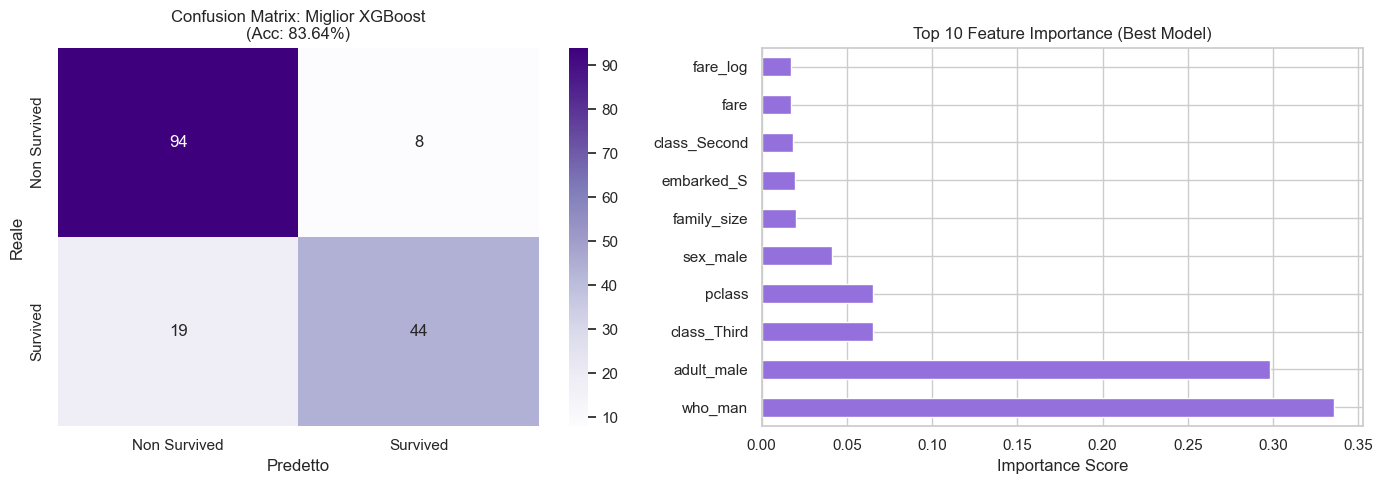

Accuratezza Finale: 83.64%

Report Tecnico Post-Tuning:
              precision    recall  f1-score   support

           0       0.83      0.92      0.87       102
           1       0.85      0.70      0.77        63

    accuracy                           0.84       165
   macro avg       0.84      0.81      0.82       165
weighted avg       0.84      0.84      0.83       165



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from xgboost import XGBClassifier

# -----------------------
# 1️⃣ Preparazione dati 
# -----------------------

y = df_encoded['survived']
X = df_encoded.drop(columns=['survived'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------
# 2️⃣ TUNING DEGLI IPERPARAMETRI (Il "Metodo")
# -----------------------

# Definiamo lo spazio di ricerca
param_dist = {
    'n_estimators': [100, 300, 500, 800],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'max_depth': [3, 4, 5, 6],
    'gamma': [0, 0.1, 0.2, 0.5],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

# Inizializziamo il modello base
xgb_base = XGBClassifier(eval_metric='logloss', random_state=42)

# Configuriamo la ricerca casuale
random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=20,           # Prova 20 combinazioni casuali
    cv=5,                # Cross-validation a 5 pieghe
    scoring='accuracy',
    verbose=1,
    n_jobs=-1,           # Usa tutti i processori disponibili
    random_state=42
)

# Avviamo la ricerca sui dati di training
random_search.fit(X_train, y_train)

# Estraiamo il modello migliore trovato
best_xgb = random_search.best_estimator_

print(f"\n✅ Migliori parametri trovati:\n{random_search.best_params_}")

# -----------------------
# 3️⃣ Predizione (usando il modello ottimizzato)
# -----------------------
y_pred = best_xgb.predict(X_test)

# -----------------------
# 📊 VISUALIZZAZIONE
# -----------------------
plt.figure(figsize=(14, 5))

# 🔹 Confusion Matrix
plt.subplot(1, 2, 1)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Non Survived', 'Survived'],
            yticklabels=['Non Survived', 'Survived'])
plt.title(f'Confusion Matrix: Miglior XGBoost\n(Acc: {accuracy_score(y_test, y_pred)*100:.2f}%)')
plt.xlabel('Predetto')
plt.ylabel('Reale')

# 🔹 Feature Importance
plt.subplot(1, 2, 2)
feat_importances = pd.Series(best_xgb.feature_importances_, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh', color='mediumpurple')
plt.title('Top 10 Feature Importance (Best Model)')
plt.xlabel('Importance Score')

plt.tight_layout()
plt.show()

# -----------------------
# 📈 Metriche Finali
# -----------------------
print(f"Accuratezza Finale: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nReport Tecnico Post-Tuning:")
print(classification_report(y_test, y_pred))

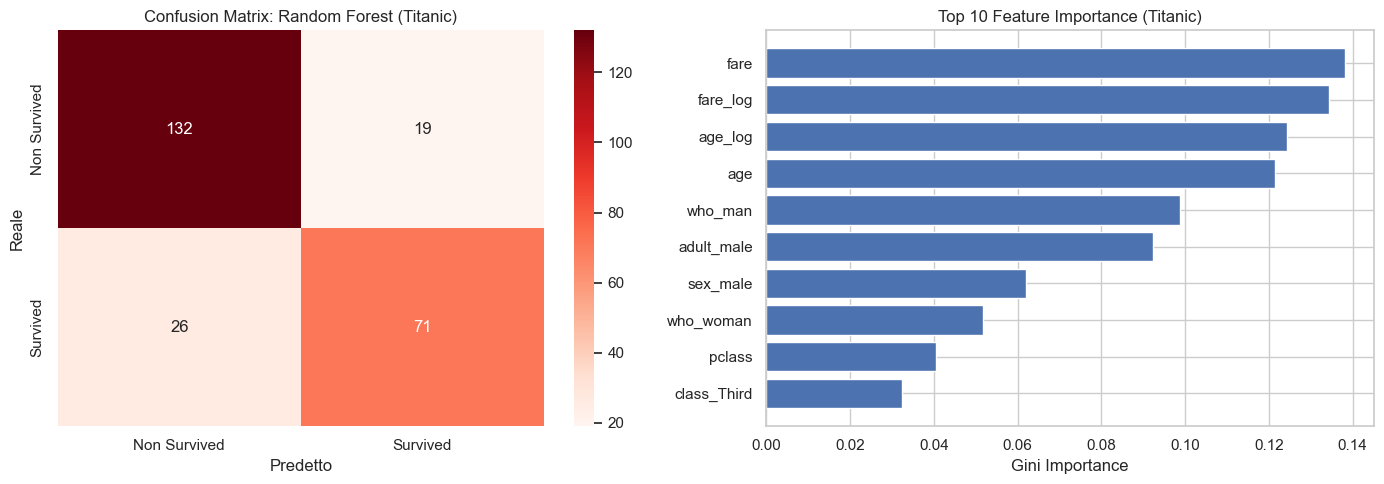

              precision    recall  f1-score   support

           0       0.84      0.87      0.85       151
           1       0.79      0.73      0.76        97

    accuracy                           0.82       248
   macro avg       0.81      0.80      0.81       248
weighted avg       0.82      0.82      0.82       248

Accuratezza Random Forest: 81.85%


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report

# 1️⃣ Target e Feature
y = df_encoded['survived']
X = df_encoded.drop(columns=['survived'])

# 2️⃣ Train/Test split (70/30 come nel tuo codice)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 3️⃣ Random Forest
rf_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42
)

rf_clf.fit(X_train, y_train)

# 4️⃣ Predizione
y_pred = rf_clf.predict(X_test)

# ---------------- VISUALIZZAZIONE ----------------
plt.figure(figsize=(14, 5))

# 🔹 Confusion Matrix
plt.subplot(1, 2, 1)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Non Survived', 'Survived'],
            yticklabels=['Non Survived', 'Survived'])
plt.title('Confusion Matrix: Random Forest (Titanic)')
plt.xlabel('Predetto')
plt.ylabel('Reale')

# 🔹 Feature Importance
plt.subplot(1, 2, 2)
importances = rf_clf.feature_importances_
indices = np.argsort(importances)[-10:]

plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.title('Top 10 Feature Importance (Titanic)')
plt.xlabel('Gini Importance')

plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred))

print(f"Accuratezza Random Forest: {accuracy_score(y_test, y_pred) * 100:.2f}%")